Nama : Ronny Rajagukguk

Kelas : Robotika A Pagi

Tugas : Transfer Learning


In [1]:
from google.colab import files

uploaded = files.upload()

Saving Datasampah.zip to Datasampah.zip


## Extract Dataset & Import Library

In [2]:
import zipfile
import os

zip_path = "/content/Datasampah.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print(os.listdir("/content"))

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

['.config', 'TrashType_Image_Dataset', 'Datasampah.zip', 'sample_data']


## Load Dataset

In [3]:
dataset_path = "/content/TrashType_Image_Dataset"

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


## Visualisasi Dataset

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


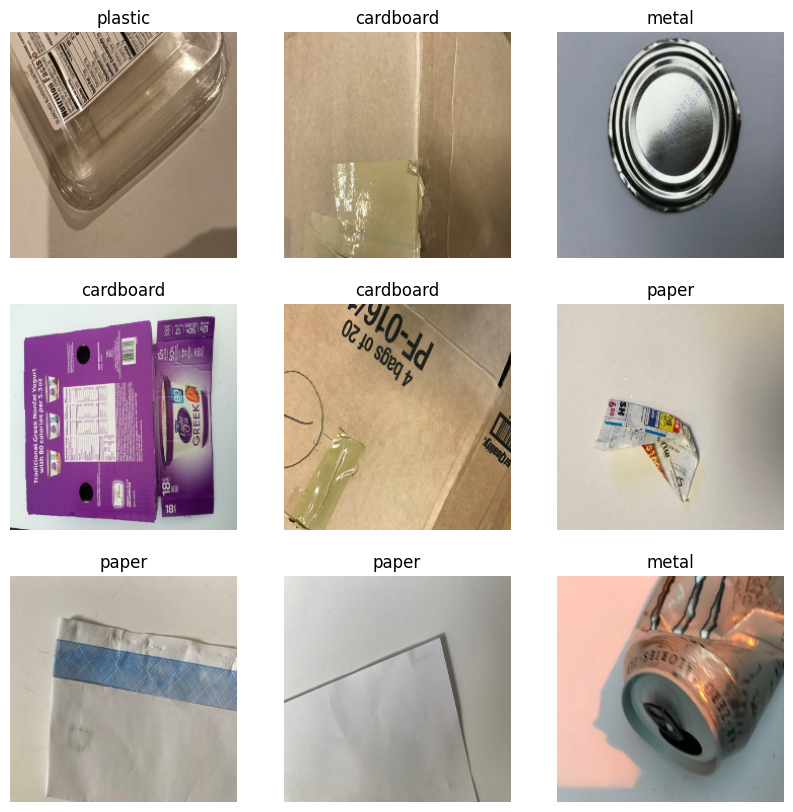

In [4]:
class_names = train_dataset.class_names

print(class_names)

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

## Data Augmentation (Handling Overfitting)

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

## Normalisasi

In [6]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

## Prefetch

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

## Import VGG16

In [8]:
from tensorflow.keras.applications import VGG16

## Load Pre-trained Model

In [9]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Freeze Layer

In [10]:
base_model.trainable = False

## Bangun Model

In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(len(class_names), activation='softmax')

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 164,998 (644.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Compile

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 164,998 (644.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## EarlyStopping

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

## Training

In [14]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=20,

    callbacks=[early_stop]

)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 218ms/step - accuracy: 0.2918 - loss: 1.6753 - val_accuracy: 0.4436 - val_loss: 1.4080
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.3872 - loss: 1.4133 - val_accuracy: 0.5248 - val_loss: 1.1945
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.4817 - loss: 1.2605 - val_accuracy: 0.5406 - val_loss: 1.1308
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.5049 - loss: 1.2021 - val_accuracy: 0.5842 - val_loss: 1.0541
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.5569 - loss: 1.1316 - val_accuracy: 0.6396 - val_loss: 0.9546
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.5554 - loss: 1.0960 - val_accuracy: 0.6257 - val_loss: 0.9283
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.5727 - loss: 1.0585 - val_accuracy: 0.6713 - val_loss: 0.8841
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.6261 - loss: 0.9739 - val_accu

## Accuracy Graph

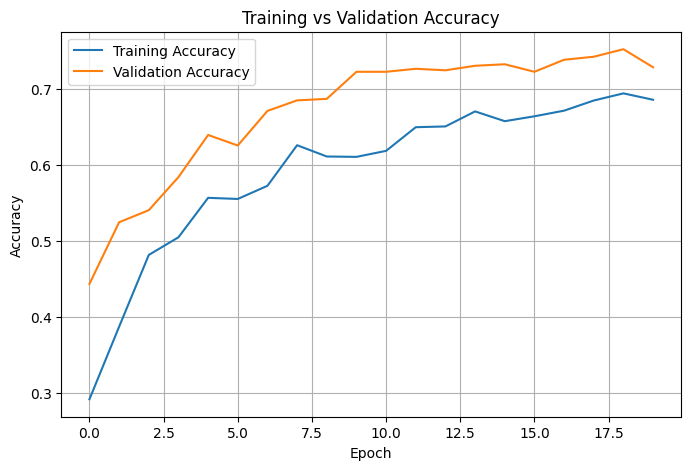

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid()

plt.show()

## Loss Graph

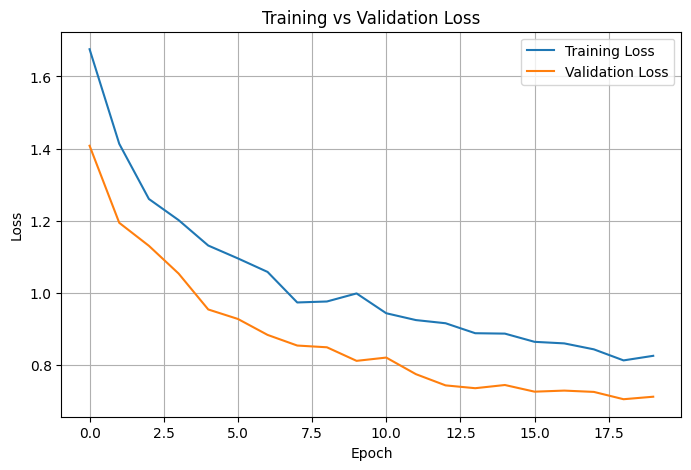

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid()

plt.show()

## Evaluasi Model

In [17]:
loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss :", loss)

print("Validation Accuracy :", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.7525 - loss: 0.7060
Validation Loss : 0.7059747576713562
Validation Accuracy : 0.7524752616882324


## Confusion Matrix

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:

    prediction = model.predict(images, verbose=0)

    prediction = np.argmax(prediction, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(prediction)

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[ 67   0   0  14   1   1]
 [  1  62  18   9  13   0]
 [  0  12  61   0   2   3]
 [  3   0   1 113   4   3]
 [  3   7   2   5  69   2]
 [  1   0   2  10   8   8]]


## Classification Report

In [19]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.89      0.81      0.85        83
       glass       0.77      0.60      0.67       103
       metal       0.73      0.78      0.75        78
       paper       0.75      0.91      0.82       124
     plastic       0.71      0.78      0.75        88
       trash       0.47      0.28      0.35        29

    accuracy                           0.75       505
   macro avg       0.72      0.69      0.70       505
weighted avg       0.75      0.75      0.74       505



## Prediksi Gambar Baru

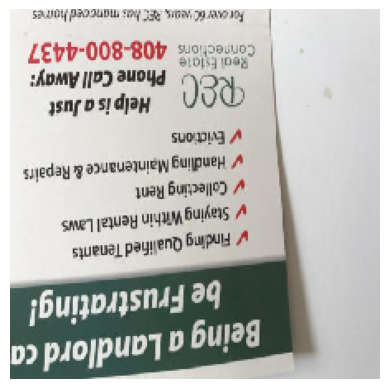

Prediksi : paper
Confidence : 99.46%


In [20]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path="/content/TrashType_Image_Dataset/paper/paper_476.jpg"

img=image.load_img(img_path,target_size=(224,224))

plt.imshow(img)

plt.axis("off")

plt.show()

img_array=image.img_to_array(img)

img_array=np.expand_dims(img_array,axis=0)

img_array=img_array/255.0

prediction=model.predict(img_array,verbose=0)

predicted_class=class_names[np.argmax(prediction)]

confidence=np.max(prediction)*100

print("Prediksi :",predicted_class)

print("Confidence : {:.2f}%".format(confidence))

Berdasarkan grafik Training Accuracy, Validation Accuracy, Training Loss, dan Validation Loss, model tidak mengalami overfitting. Hal ini ditunjukkan oleh peningkatan training dan validation accuracy yang konsisten serta penurunan training dan validation loss tanpa adanya divergensi yang signifikan. Selain itu, penggunaan teknik Data Augmentation, Dropout, dan EarlyStopping membantu model melakukan generalisasi dengan baik sehingga mampu mencapai Validation Accuracy sebesar 75,25%.